# Multisource dataset check

Notebook minimal pour valider visuellement le dataset multisource.

Il fait quatre choses :
- charge le maillage et le `conlim`,
- affiche les frontieres physiques `PRESCRIBED_Q`, `PRESCRIBED_H`, `WALL`,
- affiche les ghost nodes et verifie qu'ils lisent bien les bons `Q` dans le `.liq`,
- compare visuellement le `fine` et le `x8` sur plusieurs crues et pas de temps.


In [1]:
from pathlib import Path
import os
import pickle
import sys

import dgl
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial import Delaunay

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR
while not (PROJECT_ROOT / "python").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.ghost_nodes import add_ghost_source_nodes, extract_inlet_node_lists_from_conlim
from python.create_dgl_dataset import (
    NodeType,
    TelemacDatasetWithSourceNodes,
    load_liq_q_series,
    unpack_dynamic_sample,
)
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

# create_dgl_dataset.py changes cwd during import
os.chdir(PROJECT_ROOT)


In [16]:
BASE_BIN = "/work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m_ghost/regular_short/Aube_T1_regular_40m_base.bin"
MESH_SLF = "/work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m/Aube_regular_T1_40m.slf"

DYNAMIC_FILES = [
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/dataset_40m_ghost/regular_short/10_T1_V9_Topo3_KV5_Q30_0_27-96_interpolated.pkl",
]
HYDRO_FILES = [
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/original_dataset/T1_Q30_V1.liq",
]

INLET_NODE_LISTS = [
    [37, 38, 39, 40],
    [817, 848, 881],
    [11006, 11007, 11092, 11093],
]
SAMPLE_INDEX = 15
TIME_INDEX = 0
SEQUENCE_LENGTH = 2
DT_SECONDS = 7200.0
DEBUG_CKPT_DIR = PROJECT_ROOT / "temp" / "multisource_debug"


In [17]:
def require_file(path_like, name):
    if not path_like:
        raise ValueError(f"Fill {name} first.")
    path = Path(path_like)
    if not path.exists():
        raise FileNotFoundError(path)
    return path


def require_files(paths, name):
    if not paths:
        raise ValueError(f"Fill {name} first.")
    return [require_file(path_like, f"{name}[{idx}]") for idx, path_like in enumerate(paths)]


def node_labels_from_graph(base_graph):
    static = base_graph.ndata["static"][:, :NodeType.SIZE]
    return torch.argmax(static, dim=1).cpu().numpy()


def count_labels(labels):
    return {
        "NORMAL": int((labels == NodeType.NORMAL).sum()),
        "PRESCRIBED_H": int((labels == NodeType.PRESCRIBED_H).sum()),
        "PRESCRIBED_Q": int((labels == NodeType.PRESCRIBED_Q).sum()),
        "WALL_BOUNDARY": int((labels == NodeType.WALL_BOUNDARY).sum()),
    }


def build_ghost_xy(xy, inlet_node_lists, shift_ratio=0.04):
    center = xy.mean(axis=0)
    bbox = xy.max(axis=0) - xy.min(axis=0)
    shift = shift_ratio * float(np.linalg.norm(bbox))
    ghost_xy = []

    for inlet_nodes in inlet_node_lists:
        inlet_xy = xy[np.asarray(inlet_nodes)]
        centroid = inlet_xy.mean(axis=0)
        direction = centroid - center
        norm = float(np.linalg.norm(direction))
        if norm < 1e-12:
            direction = np.array([1.0, 0.0], dtype=np.float32)
            norm = 1.0
        ghost_xy.append(centroid + shift * direction / norm)

    return np.asarray(ghost_xy, dtype=np.float32)


def setup_axis(ax, mesh):
    ax.triplot(mesh.tri, linewidth=0.15, color="0.85")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def load_dynamic_samples(path):
    with Path(path).open("rb") as handle:
        return pickle.load(handle)


def build_interpolation_plan(fine_xy, coarse_xy):
    triangulation = Delaunay(fine_xy)
    simplex_ids = triangulation.find_simplex(coarse_xy)
    valid_mask = simplex_ids >= 0

    vertices = np.full((coarse_xy.shape[0], fine_xy.shape[1] + 1), -1, dtype=np.int64)
    weights = np.zeros((coarse_xy.shape[0], fine_xy.shape[1] + 1), dtype=np.float32)

    if np.any(valid_mask):
        valid_simplex_ids = simplex_ids[valid_mask]
        vertices[valid_mask] = triangulation.simplices[valid_simplex_ids]

        transform = triangulation.transform[valid_simplex_ids]
        delta = coarse_xy[valid_mask] - transform[:, -1, :]
        bary = np.einsum("nij,nj->ni", transform[:, :-1, :], delta)

        weights[valid_mask, :-1] = bary
        weights[valid_mask, -1] = 1.0 - bary.sum(axis=1)

    return {
        "vertices": vertices,
        "weights": weights,
        "valid_mask": valid_mask,
    }


def interpolate_scalar_field(fine_values, interpolation_plan):
    values = np.asarray(fine_values, dtype=np.float32).reshape(-1)
    output = np.zeros(interpolation_plan["weights"].shape[0], dtype=np.float32)

    valid_mask = interpolation_plan["valid_mask"]
    if np.any(valid_mask):
        vertices = interpolation_plan["vertices"][valid_mask]
        weights = interpolation_plan["weights"][valid_mask]
        gathered_values = values[vertices]
        output[valid_mask] = np.einsum("ij,ij->i", weights, gathered_values)

    return output


def extract_named_field(sample, field_name):
    x, y, ts = unpack_dynamic_sample(sample)

    if field_name == "h":
        return np.asarray(x[:, 0], dtype=np.float32), ts
    if field_name == "u":
        return np.asarray(x[:, 1], dtype=np.float32), ts
    if field_name == "v":
        return np.asarray(x[:, 2], dtype=np.float32), ts
    if field_name == "delta_h":
        return np.asarray(y[:, 0], dtype=np.float32), ts
    if field_name == "delta_u":
        return np.asarray(y[:, 1], dtype=np.float32), ts
    if field_name == "delta_v":
        return np.asarray(y[:, 2], dtype=np.float32), ts

    raise ValueError(f"Unsupported field: {field_name}")


def format_time_label(time_idx, ts):
    if ts is None:
        return f"step {time_idx}"
    return f"step {time_idx} | {ts * DT_SECONDS / 3600.0:.1f} h"


def plot_scalar_field(ax, mesh, values, title, cmap="viridis", vmin=None, vmax=None):
    artist = ax.tripcolor(mesh.tri, np.asarray(values), shading="gouraud", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return artist


def resolve_compare_label(case_idx, fine_path, compare_labels):
    if compare_labels:
        return compare_labels[case_idx]
    return Path(fine_path).stem


In [18]:
base_bin = require_file(BASE_BIN, "BASE_BIN")
mesh_slf = require_file(MESH_SLF, "MESH_SLF")
#cli_file = require_file(CLI_FILE, "CLI_FILE")
dynamic_files = require_files(DYNAMIC_FILES, "DYNAMIC_FILES")
hydro_files = require_files(HYDRO_FILES, "HYDRO_FILES")

graphs, _ = dgl.load_graphs(str(base_bin))
base_graph = graphs[0]
mesh = TelemacFile(str(mesh_slf))

xy = np.column_stack([mesh.meshx, mesh.meshy]).astype(np.float32)
labels = node_labels_from_graph(base_graph)
#inlet_node_lists = extract_inlet_node_lists_from_conlim(cli_file)
inlet_node_lists = INLET_NODE_LISTS
ghost_graph = add_ghost_source_nodes(
    base_graph,
    inlet_node_lists,
    edge_feature_dim=base_graph.edata["x"].shape[1],
)
ghost_xy = build_ghost_xy(xy, inlet_node_lists)

print(base_graph)
print("label counts:", count_labels(labels))
print("inlet count:", len(inlet_node_lists))
print("inlet sizes:", [len(nodes) for nodes in inlet_node_lists])
print("ghost graph nodes:", ghost_graph.num_nodes())
print("ghost graph source nodes:", int(ghost_graph.ndata["is_source"].sum()))


Graph(num_nodes=33863, num_edges=196566,
      ndata_schemes={'static': Scheme(shape=(6,), dtype=torch.float32)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
label counts: {'NORMAL': 30560, 'PRESCRIBED_H': 18, 'PRESCRIBED_Q': 10, 'WALL_BOUNDARY': 3275}
inlet count: 3
inlet sizes: [4, 3, 4]
ghost graph nodes: 33866
ghost graph source nodes: 3


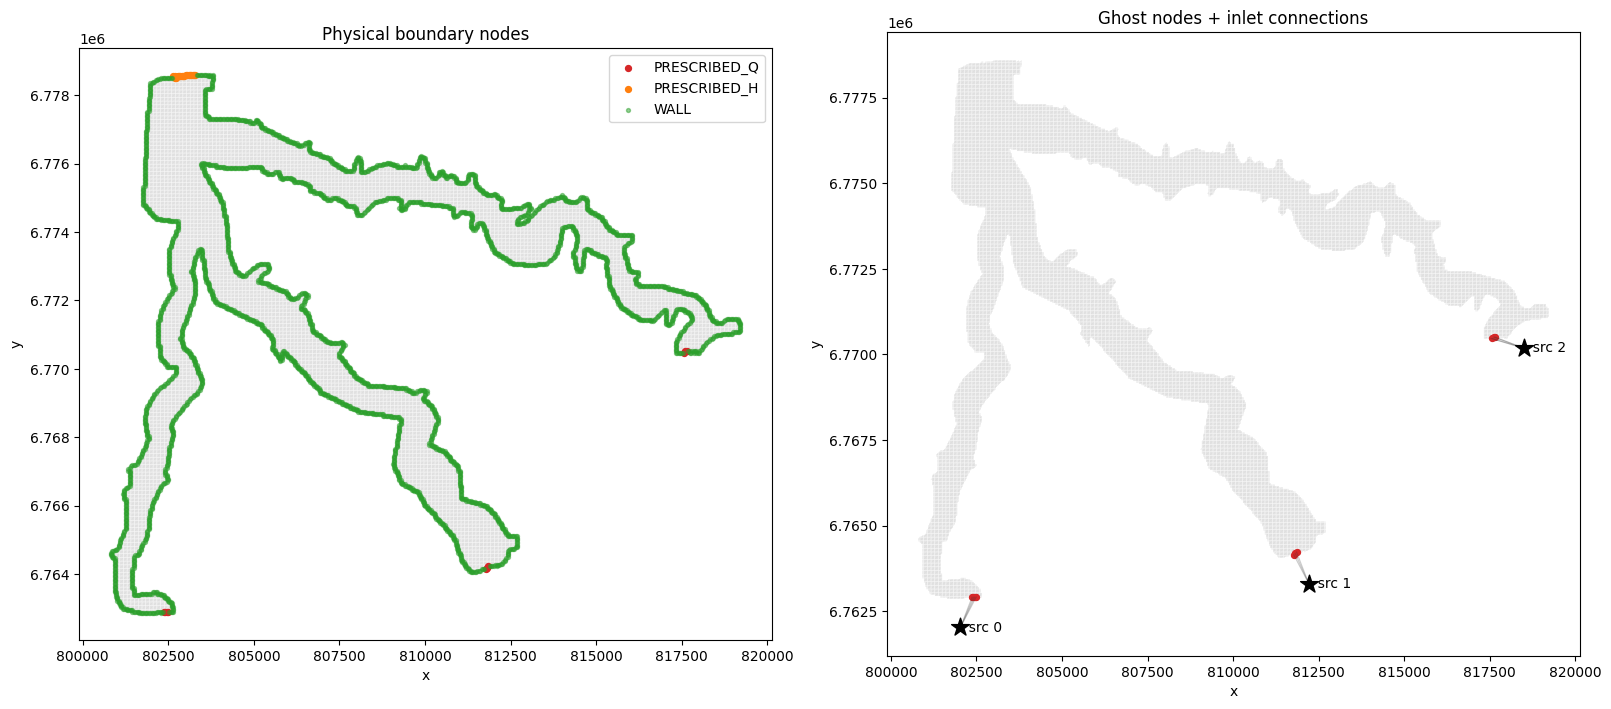

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

for ax in axes:
    setup_axis(ax, mesh)

axes[0].set_title("Physical boundary nodes")
axes[0].scatter(xy[labels == NodeType.PRESCRIBED_Q, 0], xy[labels == NodeType.PRESCRIBED_Q, 1], s=18, c="tab:red", label="PRESCRIBED_Q")
axes[0].scatter(xy[labels == NodeType.PRESCRIBED_H, 0], xy[labels == NodeType.PRESCRIBED_H, 1], s=18, c="tab:orange", label="PRESCRIBED_H")
axes[0].scatter(xy[labels == NodeType.WALL_BOUNDARY, 0], xy[labels == NodeType.WALL_BOUNDARY, 1], s=8, c="tab:green", alpha=0.5, label="WALL")
axes[0].legend(loc="best")

axes[1].set_title("Ghost nodes + inlet connections")
axes[1].scatter(xy[labels == NodeType.PRESCRIBED_Q, 0], xy[labels == NodeType.PRESCRIBED_Q, 1], s=18, c="tab:red", label="PRESCRIBED_Q")

for source_id, inlet_nodes in enumerate(inlet_node_lists):
    inlet_xy = xy[np.asarray(inlet_nodes)]
    gx, gy = ghost_xy[source_id]
    axes[1].scatter([gx], [gy], s=180, c="black", marker="*", zorder=5)
    axes[1].text(gx, gy, f"  src {source_id}", fontsize=10, va="center")
    for node_xy in inlet_xy:
        axes[1].plot([gx, node_xy[0]], [gy, node_xy[1]], color="0.2", alpha=0.25, linewidth=0.8)

plt.show()


In [20]:
DEBUG_CKPT_DIR.mkdir(parents=True, exist_ok=True)

dataset = TelemacDatasetWithSourceNodes(
    name="multisource_debug",
    data_dir=str(base_bin),
    dynamic_data_files=[str(path) for path in dynamic_files],
    hydro_data_files=[str(path) for path in hydro_files],
    inlet_node_lists=inlet_node_lists,
    use_q_feature=True,
    split="train",
    ckpt_path=str(DEBUG_CKPT_DIR),
    normalize=False,
    sequence_length=SEQUENCE_LENGTH,
    overlap=SEQUENCE_LENGTH,
    dt_seconds=DT_SECONDS,
)

sequence = dataset[SAMPLE_INDEX]
sample = sequence[TIME_INDEX]

assert int(sample["graph"].ndata["is_physical"].sum()) == sample["x_phys"].shape[0]
assert int(sample["graph"].ndata["is_source"].sum()) == sample["x_src"].shape[0]

print(sample["graph"])
print("x_phys shape:", tuple(sample["x_phys"].shape))
print("x_src shape:", tuple(sample["x_src"].shape))
print("y_phys shape:", tuple(sample["y_phys"].shape))
print("source feature names:", dataset.source_feature_names)
print("x_src:\n", sample["x_src"])


Graph(num_nodes=33866, num_edges=196577,
      ndata_schemes={'is_physical': Scheme(shape=(1,), dtype=torch.bool), 'is_source': Scheme(shape=(1,), dtype=torch.bool), 'source_id': Scheme(shape=(1,), dtype=torch.int64)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
x_phys shape: (33863, 12)
x_src shape: (3, 1)
y_phys shape: (33863, 3)
source feature names: ['q']
x_src:
 tensor([[25.9359],
        [83.9276],
        [67.1932]])


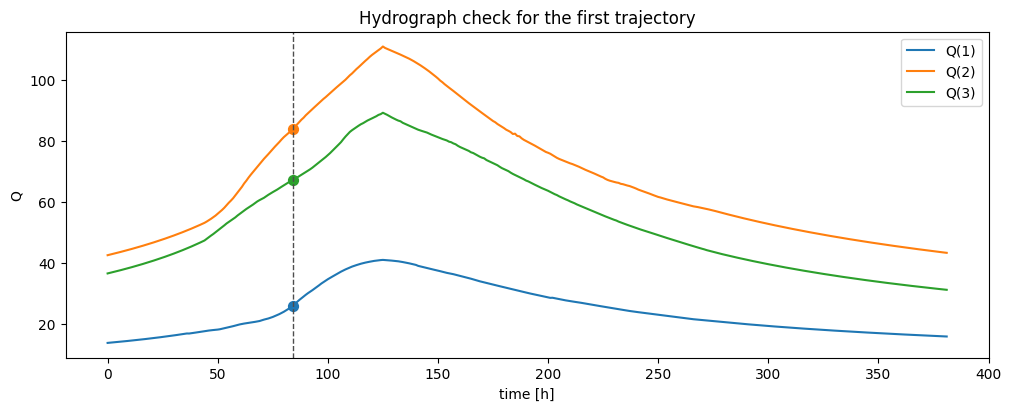

sample ts: 42
sample time [h]: 84.0
raw source features:
 [[25.935873]
 [83.92759 ]
 [67.19319 ]]


In [21]:
sample_hydro = str(hydro_files[0])
_, _, ts = unpack_dynamic_sample(dataset.sequences[SAMPLE_INDEX][TIME_INDEX])
raw_source_features = dataset._build_source_features_raw(sample_hydro, ts)
time_hours = ts * DT_SECONDS / 3600.0

t_sec, q_values, q_labels = load_liq_q_series(sample_hydro)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for source_id, label in enumerate(q_labels):
    ax.plot(t_sec / 3600.0, q_values[:, source_id], label=label)
    ax.scatter([time_hours], [raw_source_features[source_id, 0]], s=50)

ax.axvline(time_hours, color="0.3", linestyle="--", linewidth=1.0)
ax.set_xlabel("time [h]")
ax.set_ylabel("Q")
ax.set_title("Hydrograph check for the first trajectory")
ax.legend(loc="best")
plt.show()

print("sample ts:", ts)
print("sample time [h]:", time_hours)
print("raw source features:\n", raw_source_features)


## Fine vs x8 interpolation check

Cette section verifie visuellement que les fichiers `x8` correspondent bien a une projection du `fine`.

Pour chaque crue et pas de temps selectionnes, elle affiche :
- le champ sur le maillage `fine`,
- le champ stocke sur le maillage `x8`,
- le champ `fine -> x8` recalcule dans le notebook,
- l'erreur absolue `|x8 stocke - fine->x8 recalcule|`.


In [8]:
from python.create_dgl_dataset import add_mesh_info

FINE_COMPARE_MESH = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "original_dataset/T1_V9_Topo3_KV5.slf"
)
X8_COMPARE_MESH = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_40m/Aube_regular_T1_40m.slf"
)

FINE_COMPARE_FILES = [
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_40m_ghost/fine_dataset/"
    "08_T1_V9_Topo3_KV5_Q5_0_0-100.pkl",
]

X8_COMPARE_FILES = [
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_40m_ghost/regular_full/"
    "08_T1_V9_Topo3_KV5_Q5_0_0-100_interpolated.pkl",
]

COMPARE_LABELS = ["Aube T1 Q5"]
COMPARE_FIELD = "h"
COMPARE_TIME_INDICES = [47, 62, 76]
COMPARE_MAX_CASES = 1

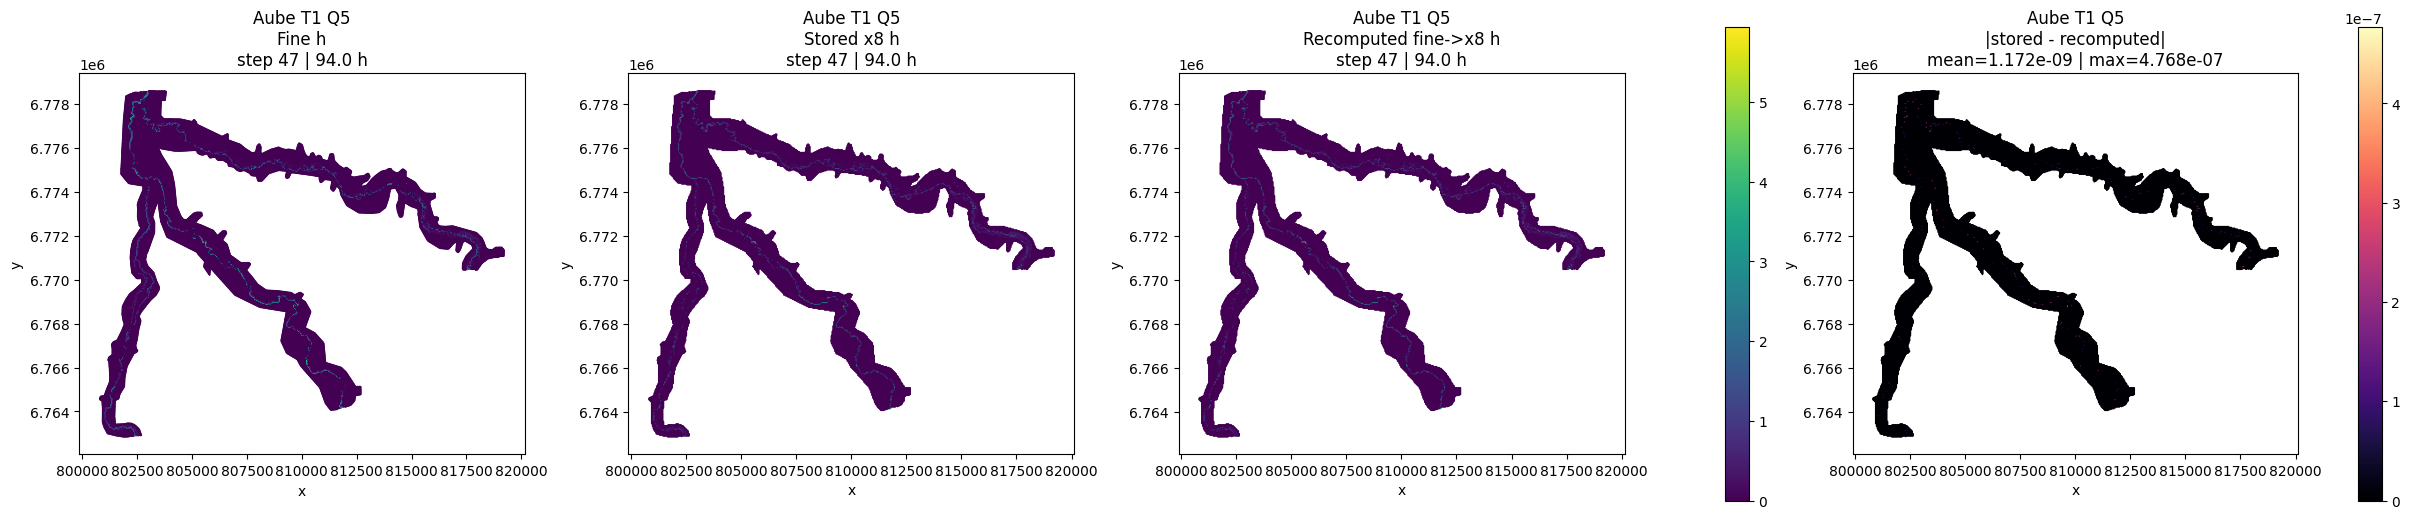

Aube T1 Q5 step 47 | 94.0 h mean_abs_diff=1.172129e-09 max_abs_diff=4.768372e-07


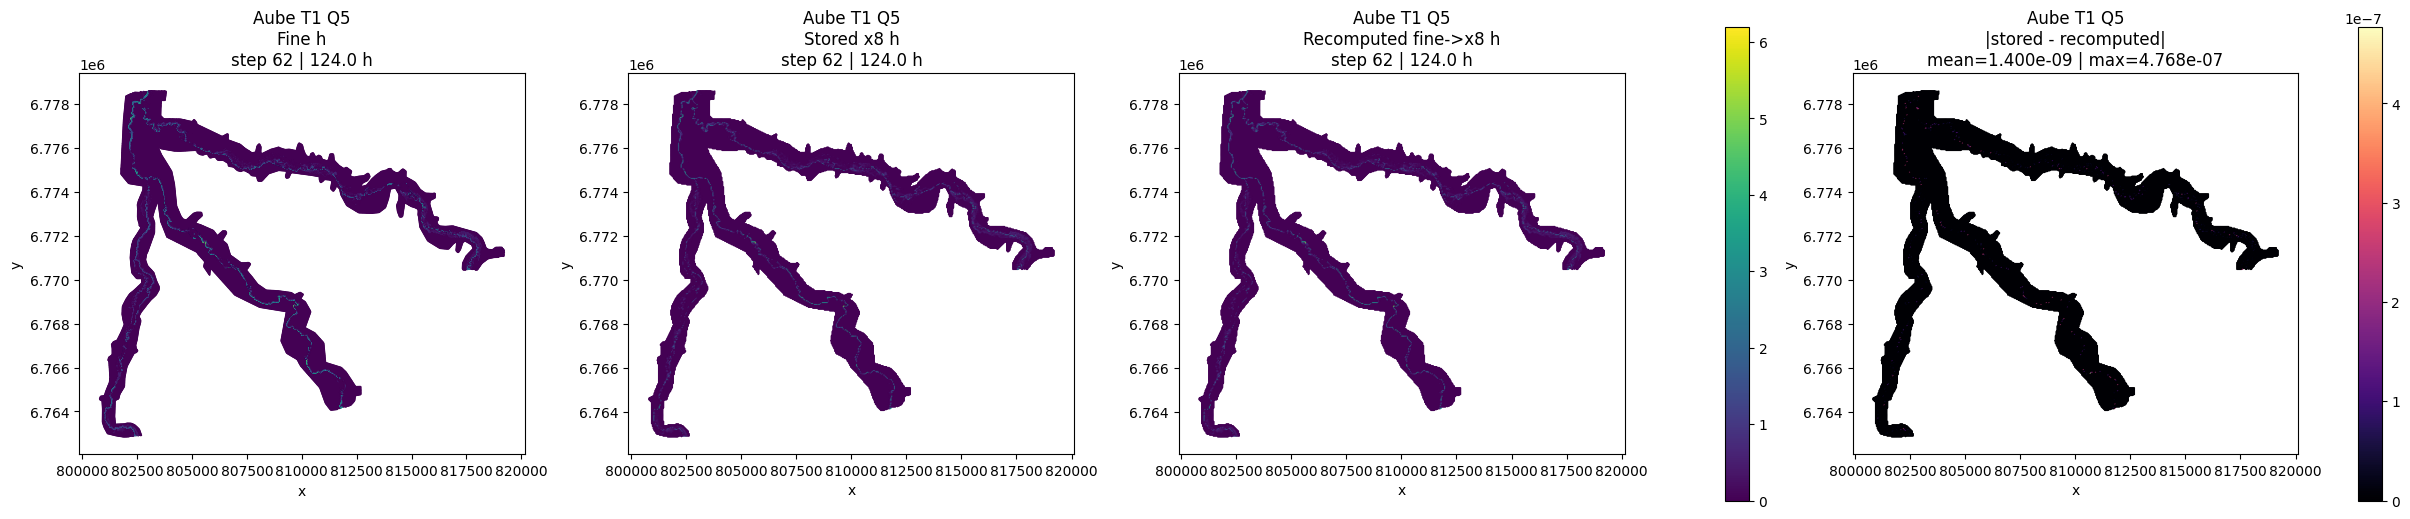

Aube T1 Q5 step 62 | 124.0 h mean_abs_diff=1.400222e-09 max_abs_diff=4.768372e-07


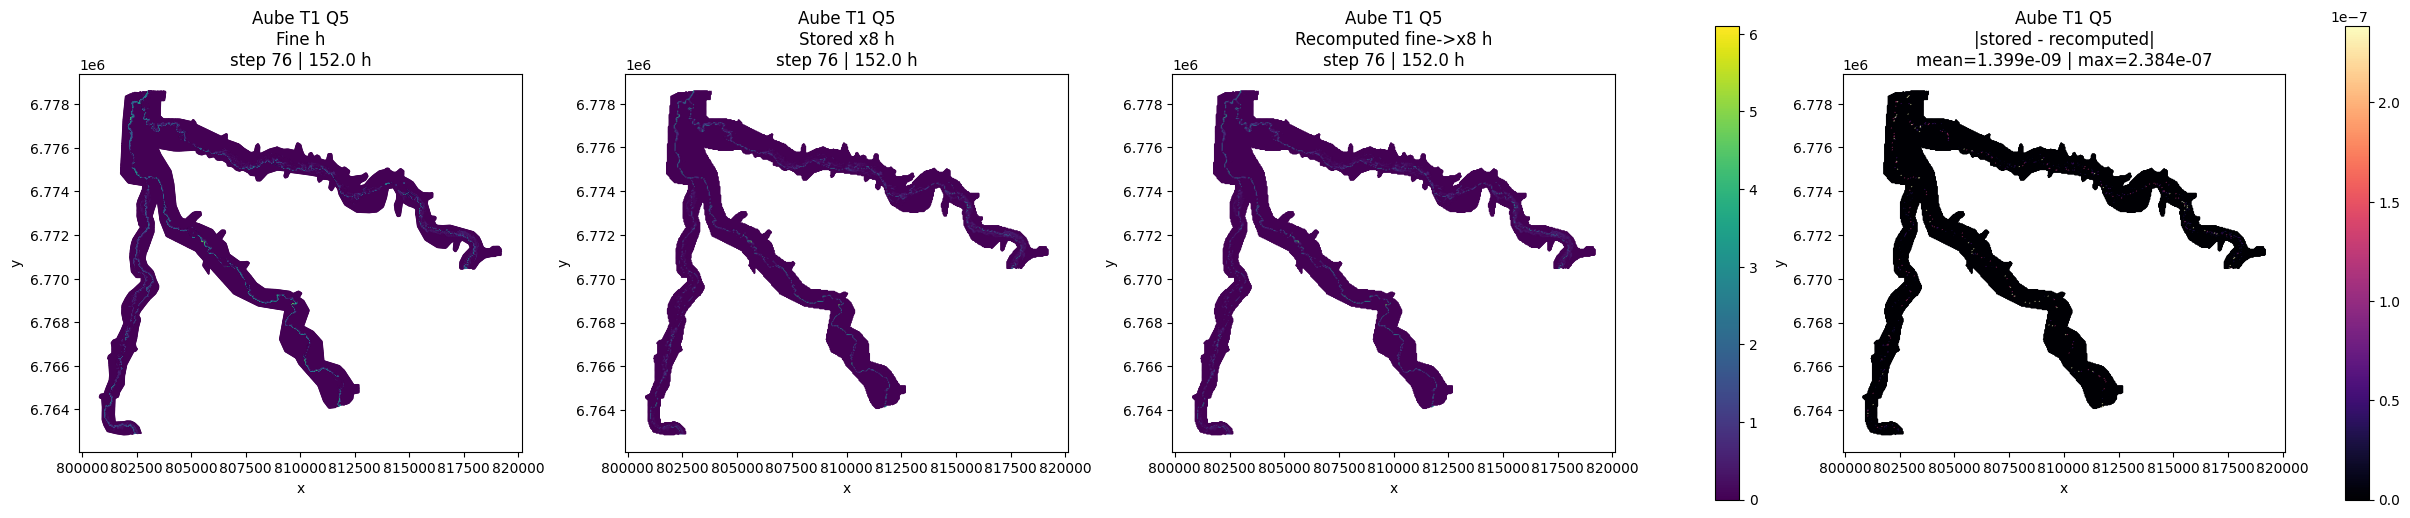

Aube T1 Q5 step 76 | 152.0 h mean_abs_diff=1.399048e-09 max_abs_diff=2.384186e-07


In [9]:
fine_compare_mesh_path = require_file(FINE_COMPARE_MESH, "FINE_COMPARE_MESH")
x8_compare_mesh_path = require_file(X8_COMPARE_MESH, "X8_COMPARE_MESH")
fine_compare_files = require_files(FINE_COMPARE_FILES, "FINE_COMPARE_FILES")
x8_compare_files = require_files(X8_COMPARE_FILES, "X8_COMPARE_FILES")

if len(fine_compare_files) != len(x8_compare_files):
    raise ValueError("FINE_COMPARE_FILES and X8_COMPARE_FILES must have the same length.")

if COMPARE_LABELS and len(COMPARE_LABELS) != len(fine_compare_files):
    raise ValueError("COMPARE_LABELS must be empty or match the number of compare files.")

fine_compare_mesh = TelemacFile(str(fine_compare_mesh_path))
x8_compare_mesh = TelemacFile(str(x8_compare_mesh_path))

fine_xy, _ = add_mesh_info(fine_compare_mesh)
x8_xy, _ = add_mesh_info(x8_compare_mesh)
compare_plan = build_interpolation_plan(fine_xy, x8_xy)

selected_case_count = len(fine_compare_files) if COMPARE_MAX_CASES is None else min(COMPARE_MAX_CASES, len(fine_compare_files))

for case_idx in range(selected_case_count):
    fine_path = fine_compare_files[case_idx]
    x8_path = x8_compare_files[case_idx]
    label = resolve_compare_label(case_idx, fine_path, COMPARE_LABELS)

    fine_samples = load_dynamic_samples(fine_path)
    x8_samples = load_dynamic_samples(x8_path)
    max_step = min(len(fine_samples), len(x8_samples))
    time_indices = [time_idx for time_idx in COMPARE_TIME_INDICES if time_idx < max_step]

    if not time_indices:
        raise ValueError(f"No valid COMPARE_TIME_INDICES for {label}. Available steps: 0..{max_step - 1}")

    for time_idx in time_indices:
        fine_field, fine_ts = extract_named_field(fine_samples[time_idx], COMPARE_FIELD)
        x8_field, x8_ts = extract_named_field(x8_samples[time_idx], COMPARE_FIELD)
        recomputed_x8_field = interpolate_scalar_field(fine_field, compare_plan)
        abs_diff = np.abs(x8_field - recomputed_x8_field)

        same_scale_fields = [fine_field, x8_field, recomputed_x8_field]
        vmin = min(float(np.min(values)) for values in same_scale_fields)
        vmax = max(float(np.max(values)) for values in same_scale_fields)
        diff_vmax = max(float(np.max(abs_diff)), 1e-12)

        caption = format_time_label(time_idx, fine_ts)
        if fine_ts != x8_ts:
            print(f"warning: ts mismatch for {label} at step {time_idx}: fine={fine_ts}, x8={x8_ts}")

        fig, axes = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

        shared_artist = plot_scalar_field(
            axes[0],
            fine_compare_mesh,
            fine_field,
            f"{label}\nFine {COMPARE_FIELD}\n{caption}",
            vmin=vmin,
            vmax=vmax,
        )
        plot_scalar_field(
            axes[1],
            x8_compare_mesh,
            x8_field,
            f"{label}\nStored x8 {COMPARE_FIELD}\n{caption}",
            vmin=vmin,
            vmax=vmax,
        )
        plot_scalar_field(
            axes[2],
            x8_compare_mesh,
            recomputed_x8_field,
            f"{label}\nRecomputed fine->x8 {COMPARE_FIELD}\n{caption}",
            vmin=vmin,
            vmax=vmax,
        )
        diff_artist = plot_scalar_field(
            axes[3],
            x8_compare_mesh,
            abs_diff,
            (
                f"{label}\n|stored - recomputed|\n"
                f"mean={float(abs_diff.mean()):.3e} | max={float(abs_diff.max()):.3e}"
            ),
            cmap="magma",
            vmin=0.0,
            vmax=diff_vmax,
        )

        fig.colorbar(shared_artist, ax=axes[:3], shrink=0.8)
        fig.colorbar(diff_artist, ax=axes[3], shrink=0.8)
        plt.show()

        print(
            label,
            caption,
            f"mean_abs_diff={float(abs_diff.mean()):.6e}",
            f"max_abs_diff={float(abs_diff.max()):.6e}",
        )


Graph(num_nodes=135475, num_edges=799594,
      ndata_schemes={'static': Scheme(shape=(6,), dtype=torch.float32)}
      edata_schemes={'x': Scheme(shape=(3,), dtype=torch.float32)})
regular label counts: {'NORMAL': 128847, 'PRESCRIBED_H': 39, 'PRESCRIBED_Q': 20, 'WALL_BOUNDARY': 6569}
regular inlet count: 3
regular inlet sizes: [6, 5, 6]
regular ghost graph nodes: 135478
regular ghost graph source nodes: 3


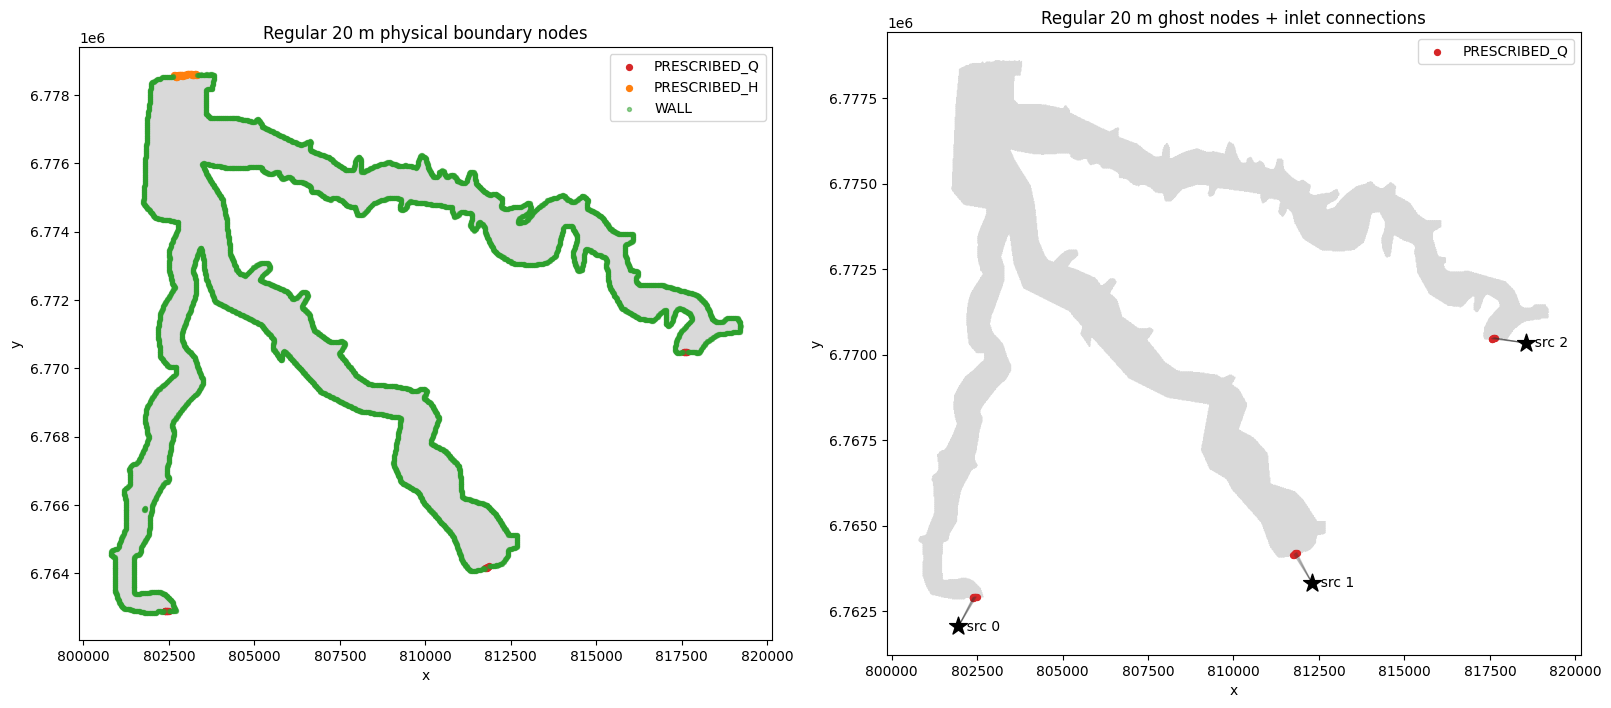

In [10]:

import json

REGULAR_BASE_BIN = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_20m_ghost/regular_full/Aube_T1_regular_20m_base.bin"
)
REGULAR_MESH_SLF = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_20m_ghost/regular_full/Aube_regular_T1_20m.slf"
)
REGULAR_INLETS_JSON = (
    "/work/m24046/m24046mrcr/Test_Aube_T1_regular/"
    "dataset_20m_ghost/regular_full/regular_inlet_node_lists.json"
)

regular_base_bin = require_file(REGULAR_BASE_BIN, "REGULAR_BASE_BIN")
regular_mesh_slf = require_file(REGULAR_MESH_SLF, "REGULAR_MESH_SLF")
regular_inlets_json = require_file(
    REGULAR_INLETS_JSON,
    "REGULAR_INLETS_JSON",
)

graphs, _ = dgl.load_graphs(str(regular_base_bin))
regular_base_graph = graphs[0]
regular_mesh = TelemacFile(str(regular_mesh_slf))

regular_xy, _ = add_mesh_info(regular_mesh)
regular_labels = node_labels_from_graph(regular_base_graph)

with regular_inlets_json.open("r", encoding="utf-8") as handle:
    regular_inlet_node_lists = json.load(handle)

regular_ghost_graph = add_ghost_source_nodes(
    regular_base_graph,
    regular_inlet_node_lists,
    edge_feature_dim=regular_base_graph.edata["x"].shape[1],
)
regular_ghost_xy = build_ghost_xy(
    regular_xy,
    regular_inlet_node_lists,
)

print(regular_base_graph)
print("regular label counts:", count_labels(regular_labels))
print("regular inlet count:", len(regular_inlet_node_lists))
print(
    "regular inlet sizes:",
    [len(nodes) for nodes in regular_inlet_node_lists],
)
print("regular ghost graph nodes:", regular_ghost_graph.num_nodes())
print(
    "regular ghost graph source nodes:",
    int(regular_ghost_graph.ndata["is_source"].sum()),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    constrained_layout=True,
)

for ax in axes:
    setup_axis(ax, regular_mesh)

axes[0].set_title("Regular 20 m physical boundary nodes")
axes[0].scatter(
    regular_xy[regular_labels == NodeType.PRESCRIBED_Q, 0],
    regular_xy[regular_labels == NodeType.PRESCRIBED_Q, 1],
    s=18,
    c="tab:red",
    label="PRESCRIBED_Q",
)
axes[0].scatter(
    regular_xy[regular_labels == NodeType.PRESCRIBED_H, 0],
    regular_xy[regular_labels == NodeType.PRESCRIBED_H, 1],
    s=18,
    c="tab:orange",
    label="PRESCRIBED_H",
)
axes[0].scatter(
    regular_xy[regular_labels == NodeType.WALL_BOUNDARY, 0],
    regular_xy[regular_labels == NodeType.WALL_BOUNDARY, 1],
    s=8,
    c="tab:green",
    alpha=0.5,
    label="WALL",
)
axes[0].legend(loc="best")

axes[1].set_title("Regular 20 m ghost nodes + inlet connections")
axes[1].scatter(
    regular_xy[regular_labels == NodeType.PRESCRIBED_Q, 0],
    regular_xy[regular_labels == NodeType.PRESCRIBED_Q, 1],
    s=18,
    c="tab:red",
    label="PRESCRIBED_Q",
)

for source_id, inlet_nodes in enumerate(regular_inlet_node_lists):
    inlet_xy = regular_xy[np.asarray(inlet_nodes)]
    gx, gy = regular_ghost_xy[source_id]

    axes[1].scatter(
        [gx],
        [gy],
        s=180,
        c="black",
        marker="*",
        zorder=5,
    )
    axes[1].text(
        gx,
        gy,
        f"  src {source_id}",
        fontsize=10,
        va="center",
    )

    for node_xy in inlet_xy:
        axes[1].plot(
            [gx, node_xy[0]],
            [gy, node_xy[1]],
            color="0.2",
            alpha=0.25,
            linewidth=0.8,
        )

axes[1].legend(loc="best")
plt.show()